주요 출력:
- horizon별 독립 XGBoost classifier의 test 성능 확인
- `y_t`, `y_t_plus_1`, `y_t_plus_2` 및 within t+2 기준 permutation feature importance
- horizon별 XGBoost built-in gain importance
- calibration, decision curve analysis(DCA)
- `RUN_SHAP = True`일 때 Tree SHAP feature importance


In [13]:
from pathlib import Path
import json
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

warnings.filterwarnings("ignore")


In [14]:
# 작업 위치
def find_project_dir() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (
            (candidate / "processed" / "data_split").exists()
            and (candidate / "models").exists()
            and (candidate / "outputs").exists()
        ):
            return candidate
        parkinson_dir = candidate / "Parkinson"
        if (
            (parkinson_dir / "processed" / "data_split").exists()
            and (parkinson_dir / "models").exists()
            and (parkinson_dir / "outputs").exists()
        ):
            return parkinson_dir
    raise FileNotFoundError("Could not locate the Parkinson project directory from the current working directory.")


PROJECT_DIR = find_project_dir()
DATA_SPLIT_DIR = PROJECT_DIR / "processed" / "data_split"
CLEAN_DATA_DIR = PROJECT_DIR / "models" / "clean_data"
MODEL_DIR = PROJECT_DIR / "models"
MODELING_OUTPUT_DIR = PROJECT_DIR / "outputs" / "modeling"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "model_interpretation"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_SPLIT_DIR:", DATA_SPLIT_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson
DATA_SPLIT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/processed/data_split
MODEL_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/models
OUTPUT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/model_interpretation


In [15]:
# 설정값 (config)
RANDOM_STATE = 42
HORIZONS = ["y_t", "y_t_plus_1", "y_t_plus_2"]
HORIZON_LABELS = {
    "y_t": "t",
    "y_t_plus_1": "t+1",
    "y_t_plus_2": "t+2",
}

MODEL_PATH = MODEL_DIR / "xgb_multi_horizon.joblib"
FEATURE_COLUMNS_PATH = CLEAN_DATA_DIR / "lstm_feature_columns.json"

EXPLAIN_SAMPLE_SIZE = 512
PERMUTATION_REPEATS = 3
TOP_N_PLOT = 25

CALIBRATION_N_BINS = 10
DCA_THRESHOLDS = np.round(np.arange(0.01, 0.81, 0.01), 2)

RUN_SHAP = False
SHAP_EXPLAIN_SIZE = 512
SHAP_HORIZON = "y_t_plus_2"


In [16]:
# seed 설정
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)


## 전처리 산출물 로딩


In [17]:
required_files = {
    "X_train": DATA_SPLIT_DIR / "X_train_lstm.npy",
    "X_test": DATA_SPLIT_DIR / "X_test_lstm.npy",
    "y_train_steps": DATA_SPLIT_DIR / "y_train_steps_lstm.npy",
    "y_test_steps": DATA_SPLIT_DIR / "y_test_steps_lstm.npy",
    "y_train_step_mask": DATA_SPLIT_DIR / "y_train_step_mask_lstm.npy",
    "y_test_step_mask": DATA_SPLIT_DIR / "y_test_step_mask_lstm.npy",
    "meta_train": DATA_SPLIT_DIR / "lstm_train_metadata.csv",
    "meta_test": DATA_SPLIT_DIR / "lstm_test_metadata.csv",
    "preprocessor": CLEAN_DATA_DIR / "lstm_preprocessor.joblib",
}

missing_files = {name: path for name, path in required_files.items() if not path.exists()}
if missing_files:
    missing_text = "\n".join(f"- {name}: {path}" for name, path in missing_files.items())
    raise FileNotFoundError(f"Missing required preprocessing outputs:\n{missing_text}")

X_train_sequence = np.load(required_files["X_train"]).astype(np.float32)
X_test_sequence = np.load(required_files["X_test"]).astype(np.float32)
y_train_steps = np.load(required_files["y_train_steps"]).astype(np.float32)
y_test_steps = np.load(required_files["y_test_steps"]).astype(np.float32)
y_train_step_mask = np.load(required_files["y_train_step_mask"]).astype(np.float32)
y_test_step_mask = np.load(required_files["y_test_step_mask"]).astype(np.float32)
meta_train = pd.read_csv(required_files["meta_train"])
meta_test = pd.read_csv(required_files["meta_test"])

# 6_modeling.ipynb의 XGB multi-horizon 모델은 anchor t 시점 feature만 입력으로 사용합니다.
X_train = X_train_sequence[:, -1, :].astype(np.float32)
X_test = X_test_sequence[:, -1, :].astype(np.float32)

if FEATURE_COLUMNS_PATH.exists():
    with open(FEATURE_COLUMNS_PATH, "r", encoding="utf-8") as f:
        feature_columns = json.load(f)
else:
    preprocessor_payload = joblib.load(required_files["preprocessor"])
    feature_columns = preprocessor_payload.get("feature_columns")
    if feature_columns is None:
        raise KeyError(
            f"{FEATURE_COLUMNS_PATH} does not exist and feature_columns was not found in "
            f"{required_files['preprocessor']}"
        )
    print("FEATURE_COLUMNS_PATH not found; loaded feature_columns from lstm_preprocessor.joblib")

if len(feature_columns) != X_train.shape[1]:
    raise ValueError(f"Feature column count mismatch: {len(feature_columns)} names vs {X_train.shape[1]} input features")

print("X_train sequence", X_train_sequence.shape)
print("X_test sequence", X_test_sequence.shape)
print("X_train anchor t", X_train.shape)
print("X_test anchor t", X_test.shape)
print("features", len(feature_columns))


X_train sequence (5532, 4, 91)
X_test sequence (2121, 4, 91)
X_train anchor t (5532, 91)
X_test anchor t (2121, 91)
features 91


In [18]:
data_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "n_examples": X_train.shape[0],
            "n_features": X_train.shape[1],
            "masked_positive_rate_within_t_plus_2": float(((y_train_steps * y_train_step_mask).max(axis=1) > 0).mean()),
            "nan_count": int(np.isnan(X_train).sum()),
        },
        {
            "split": "test",
            "n_examples": X_test.shape[0],
            "n_features": X_test.shape[1],
            "masked_positive_rate_within_t_plus_2": float(((y_test_steps * y_test_step_mask).max(axis=1) > 0).mean()),
            "nan_count": int(np.isnan(X_test).sum()),
        },
    ]
)
display(data_summary)


,split,n_examples,n_features,masked_positive_rate_within_t_plus_2,nan_count
0,train,5532,91,0.334599,0
1,test,2121,91,0.335219,0


## Multi-horizon XGBoost 모델 로딩


In [19]:
model_payload = joblib.load(MODEL_PATH)
horizon_models = model_payload["models"]

print("loaded:", MODEL_PATH)
print("architecture:", model_payload.get("model_architecture"))
print("input:", model_payload.get("input"))
print("target:", model_payload.get("target"))
print("horizons:", list(horizon_models.keys()))
print("best_params:", model_payload.get("best_params"))


loaded: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/models/xgb_multi_horizon.joblib
architecture: xgb_independent_horizon_classifiers
input: anchor_t_point_only
target: masked_t_to_t_plus_2
horizons: ['y_t', 'y_t_plus_1', 'y_t_plus_2']
best_params: {'n_estimators': 800, 'max_depth': 2, 'learning_rate': 0.008829941857246164, 'subsample': 0.987916998333937, 'colsample_bytree': 0.6449368216482472, 'min_child_weight': 5.243825554048358, 'reg_alpha': 0.01572172983174256, 'reg_lambda': 0.021510506327069925}


## 예측과 metric helper


In [20]:
def predict_proba(horizon_models: dict, x: np.ndarray) -> np.ndarray:
    probs = np.zeros((len(x), len(HORIZONS)), dtype=np.float32)
    for idx, horizon in enumerate(HORIZONS):
        probs[:, idx] = horizon_models[horizon].predict_proba(x)[:, 1]
    return probs


def safe_auprc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    y_true = np.asarray(y_true).astype(int)
    return float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else np.nan


def safe_auroc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    y_true = np.asarray(y_true).astype(int)
    return float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else np.nan


def masked_metric_summary(y_steps: np.ndarray, y_prob: np.ndarray, y_mask: np.ndarray) -> dict:
    y_prob_masked = np.where(y_mask.astype(bool), y_prob, 0.0)
    summary = {}
    horizon_auprcs = []
    horizon_aurocs = []
    for idx, horizon in enumerate(HORIZONS):
        active = y_mask[:, idx].astype(bool)
        y_true_h = y_steps[active, idx]
        y_prob_h = y_prob[active, idx]
        auprc = safe_auprc(y_true_h, y_prob_h)
        auroc = safe_auroc(y_true_h, y_prob_h)
        summary[f"{horizon}_auprc"] = auprc
        summary[f"{horizon}_auroc"] = auroc
        summary[f"{horizon}_n"] = int(active.sum())
        horizon_auprcs.append(auprc)
        horizon_aurocs.append(auroc)

    y_true_within = ((y_steps * y_mask).max(axis=1) > 0).astype(int)
    y_prob_within = 1.0 - np.prod(1.0 - y_prob_masked, axis=1)
    summary["macro_auprc"] = float(np.nanmean(horizon_auprcs))
    summary["macro_auroc"] = float(np.nanmean(horizon_aurocs))
    summary["within_t_plus_2_auprc"] = safe_auprc(y_true_within, y_prob_within)
    summary["within_t_plus_2_auroc"] = safe_auroc(y_true_within, y_prob_within)
    return summary


In [21]:
test_prob = predict_proba(horizon_models, X_test)
test_summary = masked_metric_summary(y_test_steps, test_prob, y_test_step_mask)
display(pd.DataFrame([test_summary]))


,y_t_auprc,y_t_auroc,y_t_n,y_t_plus_1_auprc,y_t_plus_1_auroc,y_t_plus_1_n,y_t_plus_2_auprc,y_t_plus_2_auroc,y_t_plus_2_n,macro_auprc,macro_auroc,within_t_plus_2_auprc,within_t_plus_2_auroc
0,0.511657,0.827804,2121,0.464393,0.759522,1944,0.437674,0.742424,1767,0.471241,0.776583,0.691461,0.820586


## Calibration, DCA


In [22]:
def build_prediction_tasks(y_steps: np.ndarray, y_prob: np.ndarray, y_mask: np.ndarray) -> dict:
    tasks = {}
    for idx, horizon in enumerate(HORIZONS):
        active = y_mask[:, idx].astype(bool)
        tasks[horizon] = {
            "label": HORIZON_LABELS[horizon],
            "y_true": y_steps[active, idx].astype(int),
            "y_prob": y_prob[active, idx].astype(float),
            "active": active,
        }

    y_prob_masked = np.where(y_mask.astype(bool), y_prob, 0.0)
    tasks["within_t_plus_2"] = {
        "label": "within t+2",
        "y_true": ((y_steps * y_mask).max(axis=1) > 0).astype(int),
        "y_prob": (1.0 - np.prod(1.0 - y_prob_masked, axis=1)).astype(float),
        "active": np.ones(len(y_steps), dtype=bool),
    }
    return tasks


def calibration_table(tasks: dict, n_bins: int = 10) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    curve_rows = []

    for task, payload in tasks.items():
        y_true = payload["y_true"]
        y_prob = np.clip(payload["y_prob"], 1e-6, 1 - 1e-6)
        observed = float(np.mean(y_true)) if len(y_true) else np.nan
        predicted = float(np.mean(y_prob)) if len(y_prob) else np.nan
        expected_observed_ratio = observed / predicted if predicted > 0 else np.nan

        summary_rows.append(
            {
                "task": task,
                "label": payload["label"],
                "n": int(len(y_true)),
                "events": int(np.sum(y_true)),
                "event_rate": observed,
                "mean_predicted_probability": predicted,
                "observed_expected_ratio": expected_observed_ratio,
                "brier_score": float(brier_score_loss(y_true, y_prob)) if len(np.unique(y_true)) == 2 else np.nan,
            }
        )

        bin_df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
        unique_prob_count = bin_df["y_prob"].nunique()
        if len(bin_df) and unique_prob_count > 1:
            bin_count = min(n_bins, unique_prob_count)
            bin_df["bin"] = pd.qcut(bin_df["y_prob"], q=bin_count, duplicates="drop")
            grouped = bin_df.groupby("bin", observed=True)
            for bin_idx, (_, group) in enumerate(grouped, start=1):
                curve_rows.append(
                    {
                        "task": task,
                        "label": payload["label"],
                        "bin": bin_idx,
                        "n": int(len(group)),
                        "events": int(group["y_true"].sum()),
                        "mean_predicted_probability": float(group["y_prob"].mean()),
                        "observed_event_rate": float(group["y_true"].mean()),
                        "min_predicted_probability": float(group["y_prob"].min()),
                        "max_predicted_probability": float(group["y_prob"].max()),
                    }
                )

    return pd.DataFrame(summary_rows), pd.DataFrame(curve_rows)


def decision_curve(tasks: dict, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for task, payload in tasks.items():
        y_true = payload["y_true"].astype(int)
        y_prob = payload["y_prob"].astype(float)
        n = len(y_true)
        prevalence = float(np.mean(y_true)) if n else np.nan

        for threshold in thresholds:
            if threshold <= 0 or threshold >= 1 or n == 0:
                continue
            y_pred = y_prob >= threshold
            tp = int(np.sum(y_pred & (y_true == 1)))
            fp = int(np.sum(y_pred & (y_true == 0)))
            odds = threshold / (1.0 - threshold)
            model_net_benefit = (tp / n) - (fp / n) * odds
            treat_all_net_benefit = prevalence - (1.0 - prevalence) * odds
            rows.extend(
                [
                    {
                        "task": task,
                        "label": payload["label"],
                        "threshold": float(threshold),
                        "strategy": "model",
                        "net_benefit": float(model_net_benefit),
                        "standardized_net_benefit": float(model_net_benefit / prevalence) if prevalence > 0 else np.nan,
                    },
                    {
                        "task": task,
                        "label": payload["label"],
                        "threshold": float(threshold),
                        "strategy": "treat_all",
                        "net_benefit": float(treat_all_net_benefit),
                        "standardized_net_benefit": float(treat_all_net_benefit / prevalence) if prevalence > 0 else np.nan,
                    },
                    {
                        "task": task,
                        "label": payload["label"],
                        "threshold": float(threshold),
                        "strategy": "treat_none",
                        "net_benefit": 0.0,
                        "standardized_net_benefit": 0.0,
                    },
                ]
            )
    return pd.DataFrame(rows)


In [23]:
test_tasks = build_prediction_tasks(y_test_steps, test_prob, y_test_step_mask)
calibration_summary, calibration_curve = calibration_table(test_tasks, n_bins=CALIBRATION_N_BINS)
dca_results = decision_curve(test_tasks, thresholds=DCA_THRESHOLDS)

calibration_summary.to_csv(OUTPUT_DIR / "xgb_multi_horizon_calibration_summary.csv", index=False)
calibration_curve.to_csv(OUTPUT_DIR / "xgb_multi_horizon_calibration_curve.csv", index=False)
dca_results.to_csv(OUTPUT_DIR / "xgb_multi_horizon_decision_curve.csv", index=False)

display(calibration_summary)


,task,label,n,events,event_rate,mean_predicted_probability,observed_expected_ratio,brier_score
0,y_t,t,2121,413,0.194719,0.411979,0.472644,0.179837
1,y_t_plus_1,t+1,1944,381,0.195988,0.447271,0.438186,0.204957
2,y_t_plus_2,t+2,1767,352,0.199208,0.450954,0.441747,0.208025
3,within_t_plus_2,within t+2,2121,711,0.335219,0.698296,0.480053,0.312565


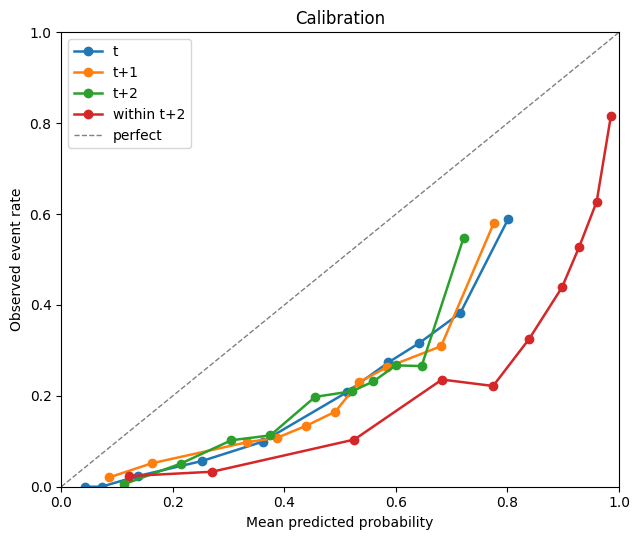

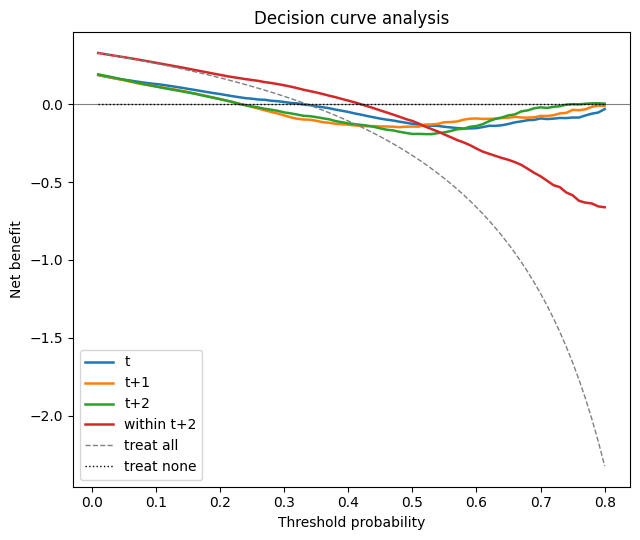

In [24]:
old_combined_figure = FIGURE_DIR / "xgb_multi_horizon_calibration_dca.png"
if old_combined_figure.exists():
    old_combined_figure.unlink()

fig, ax = plt.subplots(figsize=(6.5, 5.5))

for task, payload in test_tasks.items():
    curve = calibration_curve[calibration_curve["task"] == task]
    if curve.empty:
        continue
    ax.plot(
        curve["mean_predicted_probability"],
        curve["observed_event_rate"],
        marker="o",
        linewidth=1.8,
        label=payload["label"],
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="perfect")
ax.set_title("Calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "xgb_multi_horizon_calibration.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))

for task, payload in test_tasks.items():
    model_curve = dca_results[(dca_results["task"] == task) & (dca_results["strategy"] == "model")]
    if model_curve.empty:
        continue
    ax.plot(
        model_curve["threshold"],
        model_curve["net_benefit"],
        linewidth=1.8,
        label=payload["label"],
    )

within_all_curve = dca_results[
    (dca_results["task"] == "within_t_plus_2") & (dca_results["strategy"] == "treat_all")
]
within_none_curve = dca_results[
    (dca_results["task"] == "within_t_plus_2") & (dca_results["strategy"] == "treat_none")
]
ax.plot(within_all_curve["threshold"], within_all_curve["net_benefit"], linestyle="--", color="gray", linewidth=1, label="treat all")
ax.plot(within_none_curve["threshold"], within_none_curve["net_benefit"], linestyle=":", color="black", linewidth=1, label="treat none")
ax.set_title("Decision curve analysis")
ax.set_xlabel("Threshold probability")
ax.set_ylabel("Net benefit")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "xgb_multi_horizon_decision_curve.png", dpi=200, bbox_inches="tight")
plt.show()


## 해석 대상 subset 선택


In [26]:
X_explain_source = X_test
y_explain_steps = y_test_steps
y_explain_mask = y_test_step_mask
meta_explain = meta_test

n_explain = min(EXPLAIN_SAMPLE_SIZE, len(X_explain_source))
explain_idx = rng.choice(len(X_explain_source), size=n_explain, replace=False)
X_explain = X_explain_source[explain_idx].copy()
y_explain_steps_sub = y_explain_steps[explain_idx].copy()
y_explain_mask_sub = y_explain_mask[explain_idx].copy()
meta_explain_sub = meta_explain.iloc[explain_idx].reset_index(drop=True)

baseline_prob = predict_proba(horizon_models, X_explain)
baseline_metrics = masked_metric_summary(y_explain_steps_sub, baseline_prob, y_explain_mask_sub)
print("explain subset:", X_explain.shape)
display(pd.DataFrame([baseline_metrics]))


explain subset: (512, 91)


,y_t_auprc,y_t_auroc,y_t_n,y_t_plus_1_auprc,y_t_plus_1_auroc,y_t_plus_1_n,y_t_plus_2_auprc,y_t_plus_2_auroc,y_t_plus_2_n,macro_auprc,macro_auroc,within_t_plus_2_auprc,within_t_plus_2_auroc
0,0.510451,0.816456,512,0.495831,0.768016,471,0.478078,0.737888,427,0.494787,0.77412,0.696299,0.808955


## Permutation feature importance


In [27]:
def permutation_feature_importance(
    horizon_models: dict,
    x: np.ndarray,
    y_steps: np.ndarray,
    y_mask: np.ndarray,
    feature_names: list[str],
    repeats: int,
) -> pd.DataFrame:
    baseline_prob = predict_proba(horizon_models, x)
    baseline = masked_metric_summary(y_steps, baseline_prob, y_mask)
    feature_indices = list(range(x.shape[1]))

    rows = []
    for feature_idx in feature_indices:
        repeat_rows = []
        for repeat in range(1, repeats + 1):
            x_perm = x.copy()
            perm = rng.permutation(x_perm.shape[0])
            x_perm[:, feature_idx] = x_perm[perm, feature_idx]
            perm_prob = predict_proba(horizon_models, x_perm)
            metrics = masked_metric_summary(y_steps, perm_prob, y_mask)
            repeat_rows.append(metrics)

        repeat_df = pd.DataFrame(repeat_rows)
        row = {
            "feature_idx": feature_idx,
            "feature": feature_names[feature_idx],
            "repeats": repeats,
        }
        for metric_name, baseline_value in baseline.items():
            if metric_name.endswith("_n"):
                continue
            perm_mean = float(repeat_df[metric_name].mean())
            perm_std = float(repeat_df[metric_name].std(ddof=0))
            row[f"baseline_{metric_name}"] = baseline_value
            row[f"permuted_mean_{metric_name}"] = perm_mean
            row[f"permuted_std_{metric_name}"] = perm_std
            row[f"drop_{metric_name}"] = baseline_value - perm_mean
        rows.append(row)

    return pd.DataFrame(rows)


feature_importance = permutation_feature_importance(
    horizon_models=horizon_models,
    x=X_explain,
    y_steps=y_explain_steps_sub,
    y_mask=y_explain_mask_sub,
    feature_names=feature_columns,
    repeats=PERMUTATION_REPEATS,
)
feature_importance = feature_importance.sort_values("drop_within_t_plus_2_auprc", ascending=False).reset_index(drop=True)
feature_importance.to_csv(OUTPUT_DIR / "xgb_multi_horizon_permutation_feature_importance.csv", index=False)
display(feature_importance.head(30))


,feature_idx,feature,repeats,baseline_y_t_auprc,permuted_mean_y_t_auprc,permuted_std_y_t_auprc,drop_y_t_auprc,baseline_y_t_auroc,permuted_mean_y_t_auroc,permuted_std_y_t_auroc,...,permuted_std_macro_auroc,drop_macro_auroc,baseline_within_t_plus_2_auprc,permuted_mean_within_t_plus_2_auprc,permuted_std_within_t_plus_2_auprc,drop_within_t_plus_2_auprc,baseline_within_t_plus_2_auroc,permuted_mean_within_t_plus_2_auroc,permuted_std_within_t_plus_2_auroc,drop_within_t_plus_2_auroc
0,63,prev_delirium,3,0.510451,0.369806,0.015814,0.140645,0.816456,0.769005,0.003206,...,0.004206,0.057203,0.696299,0.592914,0.009751,0.103385,0.808955,0.760961,0.003115,0.047994
1,34,rass_max,3,0.510451,0.466787,0.006519,0.043664,0.816456,0.768438,0.011597,...,0.001137,0.023967,0.696299,0.675882,0.003573,0.020417,0.808955,0.794417,0.001285,0.014538
2,10,rass_mean,3,0.510451,0.469221,0.017465,0.041231,0.816456,0.805914,0.004090,...,0.001461,0.009593,0.696299,0.679179,0.004635,0.017119,0.808955,0.798302,0.003057,0.010653
3,22,rass_min,3,0.510451,0.453930,0.015039,0.056521,0.816456,0.787043,0.005717,...,0.002486,0.012663,0.696299,0.683597,0.002368,0.012701,0.808955,0.801958,0.001610,0.006997
4,61,sedatives,3,0.510451,0.482191,0.006805,0.028260,0.816456,0.809529,0.001393,...,0.000686,0.005497,0.696299,0.684604,0.004092,0.011695,0.808955,0.804997,0.002148,0.003958
5,51,wbc,3,0.510451,0.509430,0.003369,0.001021,0.816456,0.813026,0.001441,...,0.001237,0.002426,0.696299,0.685701,0.001819,0.010597,0.808955,0.806785,0.001564,0.002170
6,3,dbp_mean,3,0.510451,0.510790,0.000371,-0.000339,0.816456,0.816406,0.000020,...,0.000556,0.001206,0.696299,0.690087,0.000813,0.006211,0.808955,0.807890,0.000496,0.001065
7,6,gcs_verbal_mean,3,0.510451,0.497472,0.024806,0.012979,0.816456,0.805155,0.006268,...,0.001209,0.006154,0.696299,0.690295,0.007589,0.006004,0.808955,0.801750,0.000453,0.007205
8,30,gcs_verbal_max,3,0.510451,0.512125,0.005996,-0.001674,0.816456,0.820546,0.004086,...,0.002855,-0.001086,0.696299,0.691961,0.003290,0.004337,0.808955,0.811086,0.002134,-0.002131
9,11,respiratory_rate_mean,3,0.510451,0.510139,0.000117,0.000312,0.816456,0.816264,0.000062,...,0.000480,0.002107,0.696299,0.693008,0.001716,0.003290,0.808955,0.806892,0.000627,0.002063


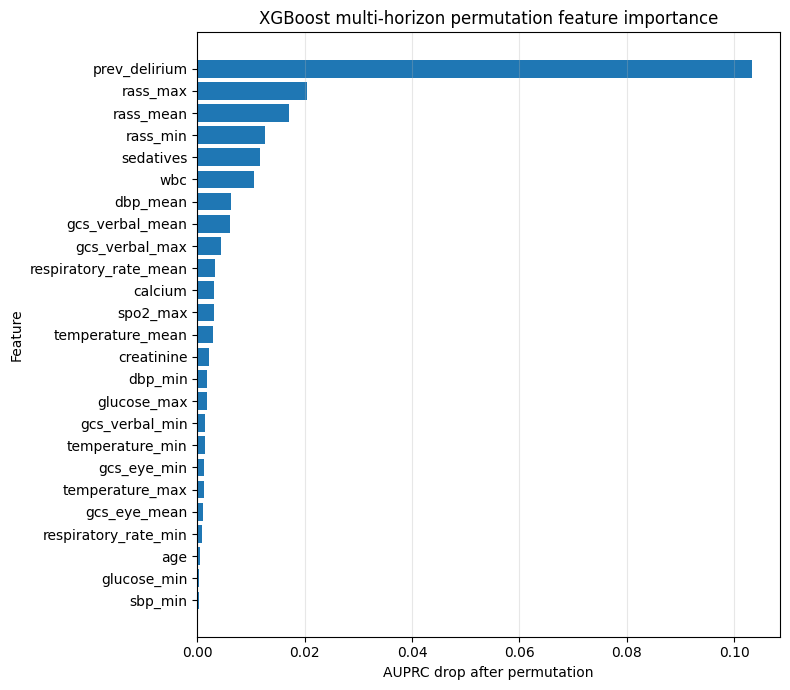

In [28]:
plot_df = feature_importance.head(TOP_N_PLOT).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(5, 0.28 * len(plot_df))))
ax.barh(plot_df["feature"], plot_df["drop_within_t_plus_2_auprc"], color="tab:blue")
ax.set_xlabel("AUPRC drop after permutation")
ax.set_ylabel("Feature")
ax.set_title("XGBoost multi-horizon permutation feature importance")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "xgb_multi_horizon_permutation_feature_importance_top.png", dpi=200, bbox_inches="tight")
plt.show()


## XGBoost built-in gain importance


In [29]:
gain_rows = []
for horizon, estimator in horizon_models.items():
    booster = estimator.get_booster()
    score = booster.get_score(importance_type="gain")
    for key, value in score.items():
        if key.startswith("f") and key[1:].isdigit():
            feature_idx = int(key[1:])
            feature = feature_columns[feature_idx]
        else:
            feature_idx = np.nan
            feature = key
        gain_rows.append(
            {
                "horizon": horizon,
                "horizon_label": HORIZON_LABELS.get(horizon, horizon),
                "feature_idx": feature_idx,
                "feature": feature,
                "gain": float(value),
            }
        )

xgb_gain_importance = pd.DataFrame(gain_rows)
xgb_gain_importance["gain_rank_within_horizon"] = xgb_gain_importance.groupby("horizon")["gain"].rank(ascending=False, method="first").astype(int)
xgb_gain_importance = xgb_gain_importance.sort_values(["horizon", "gain_rank_within_horizon"])
xgb_gain_importance.to_csv(OUTPUT_DIR / "xgb_multi_horizon_gain_feature_importance.csv", index=False)
display(xgb_gain_importance.groupby("horizon").head(15))


,horizon,horizon_label,feature_idx,feature,gain,gain_rank_within_horizon
17,y_t,t,18,gcs_verbal_min,565.271240,1
5,y_t,t,6,gcs_verbal_mean,436.534363,2
21,y_t,t,22,rass_min,167.739105,3
49,y_t,t,63,prev_delirium,118.719574,4
31,y_t,t,34,rass_max,85.823975,5
27,y_t,t,30,gcs_verbal_max,84.606857,6
9,y_t,t,10,rass_mean,75.197449,7
4,y_t,t,4,gcs_eye_mean,74.176514,8
15,y_t,t,16,gcs_eye_min,64.157997,9
48,y_t,t,61,sedatives,52.339115,10


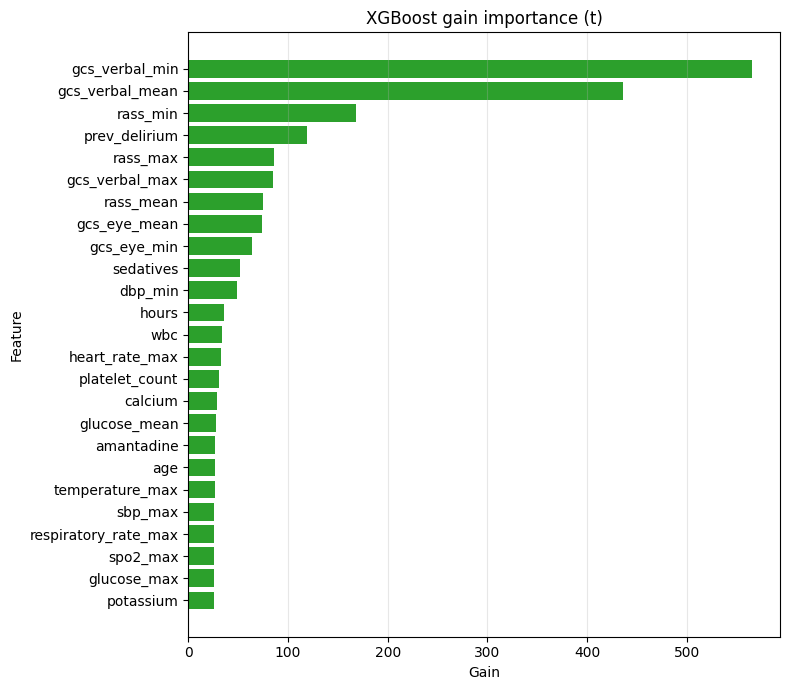

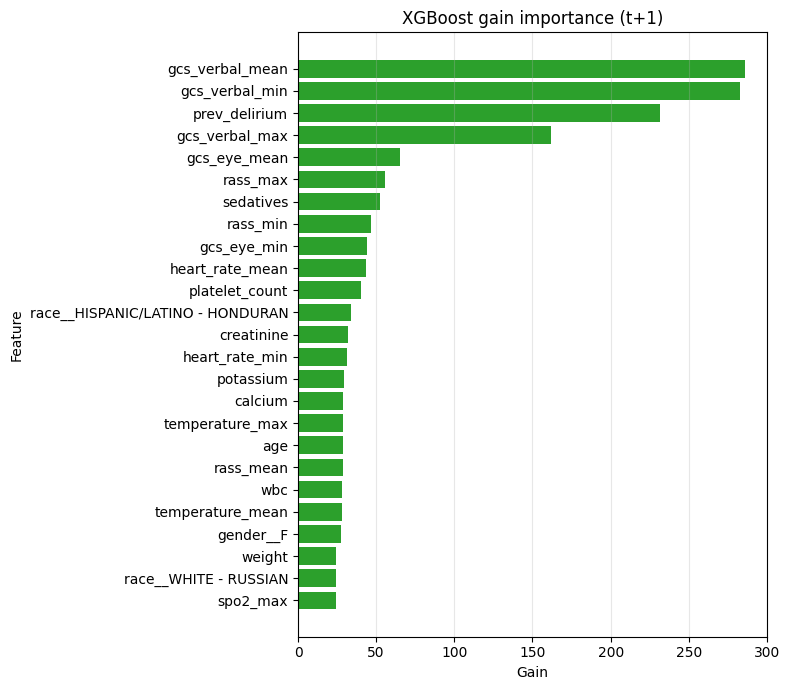

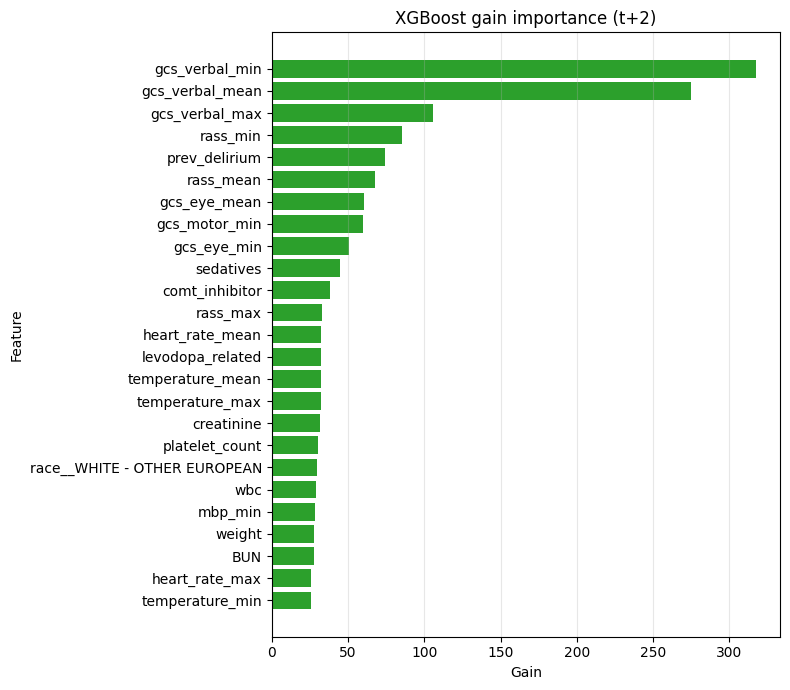

In [30]:
top_gain = xgb_gain_importance[xgb_gain_importance["gain_rank_within_horizon"] <= TOP_N_PLOT].copy()
for horizon in HORIZONS:
    plot_df = top_gain[top_gain["horizon"] == horizon].sort_values("gain").copy()
    fig, ax = plt.subplots(figsize=(8, max(5, 0.28 * len(plot_df))))
    ax.barh(plot_df["feature"], plot_df["gain"], color="tab:green")
    ax.set_xlabel("Gain")
    ax.set_ylabel("Feature")
    ax.set_title(f"XGBoost gain importance ({HORIZON_LABELS.get(horizon, horizon)})")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"xgb_multi_horizon_gain_importance_{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()


## SHAP

`RUN_SHAP = True`로 설정한 경우 선택한 horizon의 XGBoost tree model을 Tree SHAP으로 설명합니다.


In [31]:
print("RUN_SHAP:", RUN_SHAP)

if RUN_SHAP:
    import shap

    if SHAP_HORIZON not in horizon_models:
        raise ValueError(f"Unknown SHAP_HORIZON: {SHAP_HORIZON}")

    ex_n = min(SHAP_EXPLAIN_SIZE, len(X_explain))
    shap_x = X_explain[:ex_n]
    shap_model = horizon_models[SHAP_HORIZON]
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(shap_x)
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]

    mean_abs_by_feature = np.abs(shap_values).mean(axis=0)
    shap_feature_importance = pd.DataFrame(
        {
            "feature_idx": np.arange(len(feature_columns)),
            "feature": feature_columns,
            "mean_abs_shap": mean_abs_by_feature,
            "horizon": SHAP_HORIZON,
            "horizon_label": HORIZON_LABELS.get(SHAP_HORIZON, SHAP_HORIZON),
        }
    ).sort_values("mean_abs_shap", ascending=False)
    shap_feature_importance.to_csv(OUTPUT_DIR / "xgb_multi_horizon_shap_feature_importance.csv", index=False)
    display(shap_feature_importance.head(30))

    plot_df = shap_feature_importance.head(TOP_N_PLOT).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(5, 0.28 * len(plot_df))))
    ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="tab:purple")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("Feature")
    ax.set_title(f"XGBoost SHAP feature importance ({HORIZON_LABELS.get(SHAP_HORIZON, SHAP_HORIZON)})")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "xgb_multi_horizon_shap_feature_importance_top.png", dpi=200, bbox_inches="tight")
    plt.show()


RUN_SHAP: False


## 저장된 산출물


In [32]:
saved_files = sorted([str(path.relative_to(PROJECT_DIR)) for path in OUTPUT_DIR.glob("xgb_multi_horizon*.csv")])
saved_figures = sorted([str(path.relative_to(PROJECT_DIR)) for path in FIGURE_DIR.glob("xgb_multi_horizon*.png")])
print("XGBoost CSV outputs:")
for path in saved_files:
    print("-", path)
print("XGBoost figure outputs:")
for path in saved_figures:
    print("-", path)


XGBoost CSV outputs:
- outputs/model_interpretation/xgb_multi_horizon_calibration_curve.csv
- outputs/model_interpretation/xgb_multi_horizon_calibration_summary.csv
- outputs/model_interpretation/xgb_multi_horizon_decision_curve.csv
- outputs/model_interpretation/xgb_multi_horizon_gain_feature_importance.csv
- outputs/model_interpretation/xgb_multi_horizon_permutation_feature_importance.csv
XGBoost figure outputs:
- outputs/model_interpretation/figures/xgb_multi_horizon_calibration.png
- outputs/model_interpretation/figures/xgb_multi_horizon_decision_curve.png
- outputs/model_interpretation/figures/xgb_multi_horizon_gain_importance_y_t.png
- outputs/model_interpretation/figures/xgb_multi_horizon_gain_importance_y_t_plus_1.png
- outputs/model_interpretation/figures/xgb_multi_horizon_gain_importance_y_t_plus_2.png
- outputs/model_interpretation/figures/xgb_multi_horizon_permutation_feature_importance_top.png
